# FIRST STEPS IN QISKIT

In this notebook, we are going to learn how to use Qiskit to define a simple circuit and to execute it on both simulators and the quantum computers of the IBM Quantum Experience.. 

We start by importing the necessary packages.

## Defining the circuit

Now, we are going to define a very simple circuit: we will use the $H$ gate to put a qubit in superposition and then we will measure it

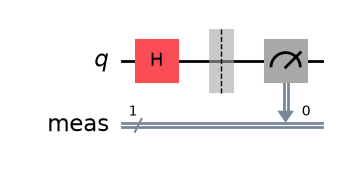

In [1]:
%matplotlib inline

from qiskit import QuantumCircuit, qasm2

qc = QuantumCircuit(1) # a circuit with one qubit 

qc.h(0) # apply the H gate

qc.measure_all()

qc.draw("mpl"); # draw the circuit

In [2]:
# obtaining the "qasm" code for the circuit.

print(qasm2.dumps(qc))

OPENQASM 2.0;
include "qelib1.inc";
qreg q[1];
creg meas[1];
h q[0];
barrier q[0];
measure q[0] -> meas[0];


## Running the circuit on simulators

- Simulator Provider: `AerProvider()`  Provider for Aer backends.

- Simulator Backends: `AerSimulator([configuration, properties, ...])` 


## Simulation Method Options:
1. automatic (default simulation method)
2. statevector
3. density_matrix
4. stabilizer
5. extended_stabilizer
6. matrix_product_state
7. unitary
8. superop

In [3]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()

print(simulator.available_devices())
print(simulator.available_methods())

('CPU',)
('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')


[{'0': 537, '1': 463}, {'0': 509, '1': 491}, {'0': 486, '1': 514}, {'1': 513, '0': 487}, {'1': 486, '0': 514}]


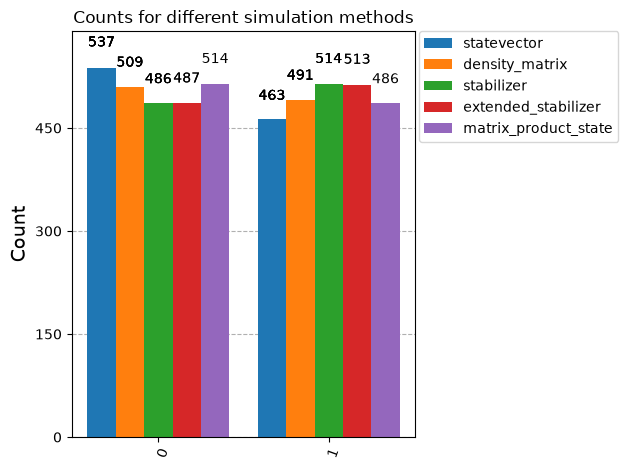

In [4]:
from qiskit.visualization import plot_histogram, plot_state_city


shots = 1000

# Statevector simulation method
sim_statevector = AerSimulator(method='statevector')
job_statevector = sim_statevector.run(qc, shots=shots)
counts_statevector = job_statevector.result().get_counts(0)

# Stabilizer simulation method
sim_stabilizer = AerSimulator(method='stabilizer')
job_stabilizer = sim_stabilizer.run(qc, shots=shots)
counts_stabilizer = job_stabilizer.result().get_counts(0)


# Extended Stabilizer method
sim_extstabilizer = AerSimulator(method='extended_stabilizer')
job_extstabilizer = sim_extstabilizer.run(qc, shots=shots)
counts_extstabilizer = job_extstabilizer.result().get_counts(0)

# Density Matrix simulation method
sim_density = AerSimulator(method='density_matrix')
job_density = sim_density.run(qc, shots=shots)
counts_density = job_density.result().get_counts(0)

# Matrix Product State simulation method
sim_mps = AerSimulator(method='matrix_product_state')
job_mps = sim_mps.run(qc, shots=shots)
counts_mps = job_mps.result().get_counts(0)

print([ counts_statevector,counts_stabilizer ,counts_extstabilizer, counts_density, counts_mps])
plot_histogram([ counts_statevector,counts_stabilizer ,counts_extstabilizer, counts_density, counts_mps],
               title='Counts for different simulation methods',
               legend=[ 'statevector',
                       'density_matrix',
                       'stabilizer',
                       'extended_stabilizer', 
                       'matrix_product_state']
                );


In [5]:
# CPU Simulation

from qiskit_aer import AerError

# Initialize a CPU backend
try:
    simulator_gpu = AerSimulator(method='statevector', device='CPU')

except AerError as e:
    print(e)


job = simulator_gpu.run(qc, shots=shots)
count = job.result().get_counts(0)
print(count)

{'1': 515, '0': 485}


### Obtaining the state vector

In [6]:
qc2 = QuantumCircuit(1)

qc2.h(0) # Apply Hadamard gate
qc2.save_statevector() # store the final quantum state in the result object

simulator = AerSimulator(method="statevector")

job = simulator.run(qc2)
result = job.result()

state = result.get_statevector(qc2)

print(state)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


### And Obtaining the state vector directly with `quantum_info` module through `qi`

1. qi.Statevector
2. qi.DensityMatrix
3. qi.Operator
3. qi.Pauli
4. qi.SparsePauliOp

In [7]:
# Execution to the get the statevector

import qiskit.quantum_info as qi

qc3 = QuantumCircuit(1)

qc3.h(0) 
state = qi.Statevector.from_instruction(qc3) # Obtain the statevector directly

print(state)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


### obtaining the unitary matrix that represents the action of the circuit

In [8]:
unitary = qi.Operator(qc3)

print(unitary.data)

[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]


Now, we are going to use the quantum computers at the IBM Quantum Experience to use our circuit 

In [9]:
# Connecting to the real quantum computers

from qiskit_ibm_runtime import QiskitRuntimeService


service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-09-03 01:16:22,661: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


In [10]:
# service.backends(simulator=False, operational=True, min_num_qubits=100)
# backend = service.least_busy(simulator=False, operational=True)
service.backends()


qiskit_runtime_service.backends:WARNING:2026-09-03 01:16:23,779: Loading instance: open-instance, plan: open


[<IBMBackend('ibm_fez')>,
 <IBMBackend('ibm_marrakesh')>,
 <IBMBackend('ibm_kingston')>]

We can execute the circuit on IBM's quantum simulator (supports up to 32 qubits). We only need to select the appropriate backend.

qiskit_runtime_service.backends:WARNING:2026-09-03 01:16:26,462: Using instance: open-instance, plan: open


{'1': 524, '0': 500}


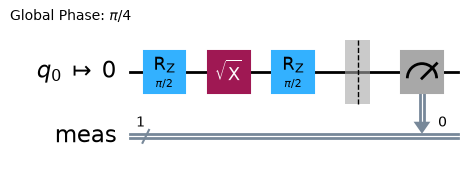

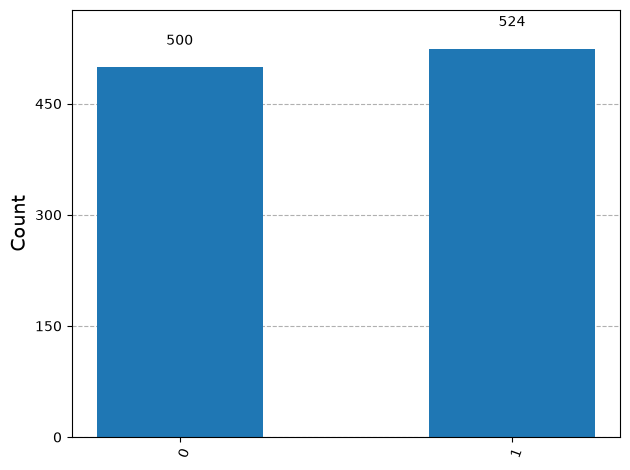

In [11]:
# Executing on the IBM Q Experience simulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram

backend = service.backend("ibm_fez")

sampler = Sampler(mode=backend)

# Convert to an ISA circuit and layout-mapped observables.
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1
)
isa_qc = pm.run(qc)
job_exp = sampler.run([isa_qc], shots=1024) 

result_exp = job_exp.result()

counts_exp = result_exp[0].data.meas.get_counts()

isa_qc.draw("mpl", idle_wires=False)
print(counts_exp)
plot_histogram(counts_exp);

To execute on one of the real quantum computers, we only need to select it as backend. We will use *job_monitor* to have live information on the job status 

When the job is done, we can collect the results and compare them to the ones obtaine with the simulator

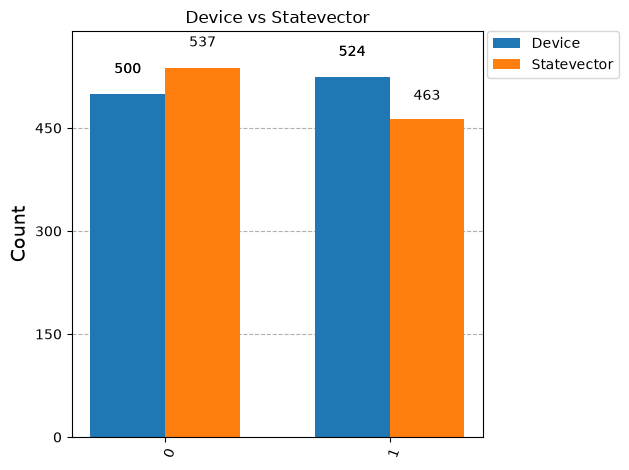

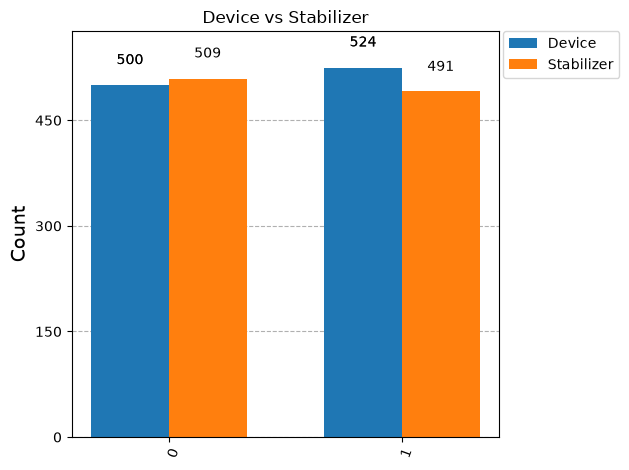

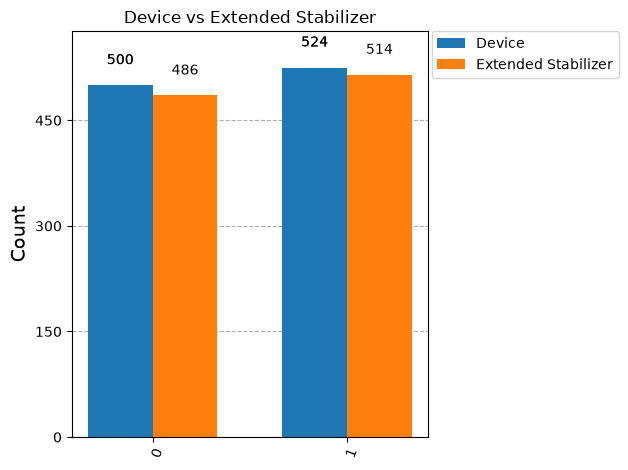

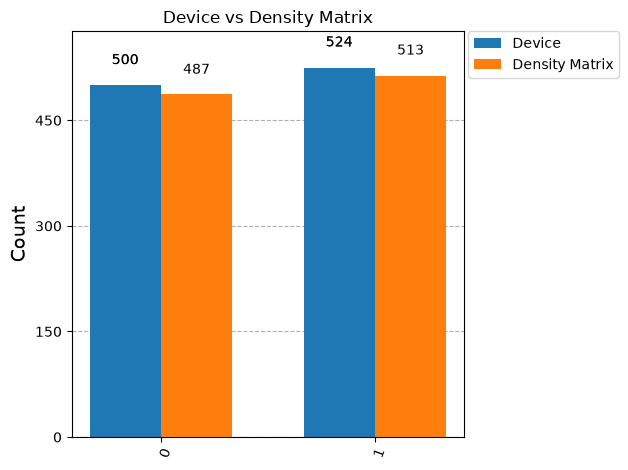

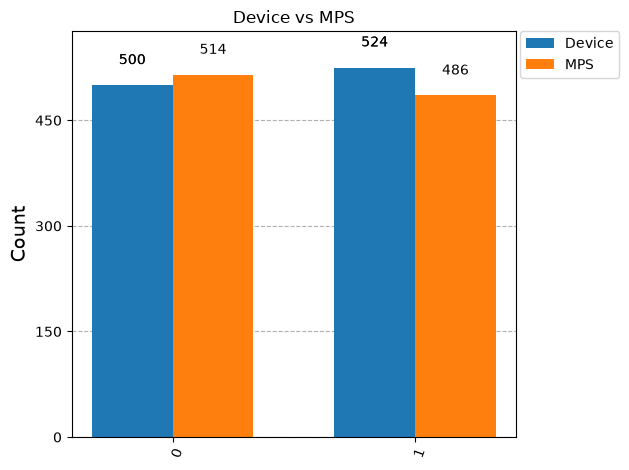

In [15]:
# Compare hardware vs simulator

from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

simulators = {
    "Statevector": counts_statevector,
    "Stabilizer": counts_stabilizer,
    "Extended Stabilizer": counts_extstabilizer,
    "Density Matrix": counts_density,
    "MPS": counts_mps
}

for name, counts_sim in simulators.items():
    plot_histogram(
        [counts_exp, counts_sim],
        legend=["Device", name],
        title=f"Device vs {name}"
    )
    plt.show()